In [56]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

### Read the input file and check the data dimension

In [2]:
df = pd.read_csv("german_credit.csv")

In [3]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [4]:
df = df.sample(n=500)
#X =  df.drop("default", axis=1)
#y =  df.pop("default")

In [5]:
# Lets build a Ensemble model but need to modify the dataset first
#test_size = 0.30 # taking 50:50 training and test set
#seed = 7  # Random numbmer seeding for reapeatability of the code
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [6]:
# Print Shape of model data
df.shape

(500, 21)

In [7]:
df_t = pd.get_dummies(df)

In [8]:
df_t.head(10)

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
536,0,6,1374,4,3,75,1,1,0,1,...,1,0,1,0,0,0,0,1,0,1
225,0,36,2613,4,2,27,2,1,0,0,...,1,0,0,1,0,0,1,0,0,1
46,0,36,2299,4,4,39,1,1,0,0,...,1,0,0,1,0,0,1,0,0,1
532,0,12,1503,4,4,41,1,1,0,0,...,0,1,0,1,0,0,1,0,0,1
146,0,6,860,1,4,39,2,1,0,1,...,1,0,0,1,0,0,0,1,0,1
314,0,4,1494,1,2,29,1,2,0,0,...,1,0,0,0,0,1,1,0,1,0
448,0,12,1424,3,4,55,1,1,0,0,...,1,0,1,0,0,0,0,1,0,1
797,0,12,1258,2,4,22,2,1,0,0,...,0,1,0,0,0,1,1,0,0,1
632,0,15,1444,4,1,23,1,1,1,0,...,1,0,0,1,0,0,1,0,0,1
380,0,20,2212,4,4,39,1,1,0,1,...,1,0,0,1,0,0,0,1,0,1


In [12]:
df_t.shape

(500, 62)

### Check for highly correlated variables but don't required any treatment for this use case

In [13]:
df.corr()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,...,property_unknown / no property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",foreign_worker_yes
default,1.000000,0.207971,0.152248,0.077223,0.022355,-0.037202,-0.058348,0.024015,0.313155,-0.053772,...,0.187231,-0.101813,0.045798,-0.199853,0.108777,0.022354,0.032496,-0.035454,-0.021097,0.091492
duration_in_month,0.207971,1.000000,0.642125,-0.028408,-0.004575,-0.056715,-0.029032,0.006456,0.004305,-0.089012,...,0.248160,-0.061466,0.090081,-0.105471,-0.089507,0.104118,-0.053516,-0.181973,0.180334,0.154653
credit_amount,0.152248,0.642125,1.000000,-0.316405,0.005844,0.030922,0.014250,0.033749,-0.023297,-0.137365,...,0.286588,-0.051201,0.045860,-0.151023,-0.026295,-0.044735,-0.053514,-0.175878,0.299842,0.089761
installment_as_income_perc,0.077223,-0.028408,-0.316405,1.000000,0.039058,0.031275,0.005420,-0.092879,0.019764,-0.022615,...,0.045174,-0.029760,0.050086,0.023164,-0.070040,0.022745,-0.059570,-0.038530,-0.037480,0.104488
present_res_since,0.022355,-0.004575,0.005844,0.039058,1.000000,0.260490,0.079977,0.087414,0.087862,-0.070342,...,0.232377,0.006272,-0.043450,-0.352973,0.204687,-0.008248,-0.080928,0.021945,0.097300,0.063149
age,-0.037202,-0.056715,0.030922,0.031275,0.260490,1.000000,0.148117,0.150454,-0.019958,0.047436,...,0.237508,-0.068561,0.003669,-0.075325,-0.178713,-0.183196,0.053783,0.070084,0.143943,-0.001320
credits_this_bank,-0.058348,-0.029032,0.014250,0.005420,0.079977,0.148117,1.000000,0.103020,-0.070119,-0.008529,...,-0.017829,-0.081010,0.025748,0.032337,-0.062141,0.012492,0.112480,-0.001875,0.038878,-0.037179
people_under_maintenance,0.024015,0.006456,0.033749,-0.092879,0.087414,0.150454,0.103020,1.000000,0.059449,0.038417,...,0.060853,-0.058299,-0.044554,-0.044698,-0.066988,-0.105454,0.007319,0.137415,0.008613,-0.092280
account_check_status_< 0 DM,0.313155,0.004305,-0.023297,0.019764,0.087862,-0.019958,-0.070119,0.059449,1.000000,-0.183033,...,0.040316,0.029437,0.001772,-0.124154,0.098220,0.029470,-0.019701,0.009625,-0.071588,-0.093986
account_check_status_>= 200 DM / salary assignments for at least 1 year,-0.053772,-0.089012,-0.137365,-0.022615,-0.070342,0.047436,-0.008529,0.038417,-0.183033,1.000000,...,0.020356,-0.030016,-0.005345,0.007369,-0.038131,-0.032111,0.110627,-0.001367,-0.026517,-0.068466


### Drop the original variables which are converted to dummy

In [16]:
df = pd.get_dummies(df ,drop_first =True )

In [17]:
df.shape

(500, 49)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [19]:
X =  df.drop("default", axis=1)
y =  df.pop("default")

In [20]:
test_size = 0.30 # taking 70:50 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [21]:
Rf_model = RandomForestClassifier(criterion='entropy',random_state=0 )

#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'n_estimators':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(Rf_model,parameter,cv=3)
GS.fit(X,y)

C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'n_estimators': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [22]:
GS.best_params_

{'criterion': 'gini', 'n_estimators': 4}

In [23]:
Rf_model = RandomForestClassifier(n_estimators=500,n_jobs=2,criterion='entropy',random_state=9999 )

In [26]:
Rf_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [29]:
# make predictions
from sklearn import metrics
predicted = Rf_model.predict(X_test)

In [31]:
acc2=metrics.accuracy_score(y_test,predicted)
print("Accuracy score : " ,acc2)

Accuracy score :  0.7466666666666667


In [32]:
cm=metrics.confusion_matrix(y_test,predicted)
print(cm)

[[93  8]
 [30 19]]


### Q6 Show the list of the features importance( 1 Marks)

[6.63644756e-02 9.95215728e-02 4.08931690e-02 3.80592887e-02
 8.69865743e-02 2.00191295e-02 1.06559047e-02 3.79876278e-02
 8.42141229e-03 9.16656917e-02 5.14589471e-02 7.12707905e-03
 2.59321112e-02 9.03791918e-03 7.67889022e-03 1.87386483e-02
 9.01818916e-03 1.66350473e-02 3.16576385e-03 5.68153782e-05
 1.24004956e-02 4.57743666e-03 1.58276173e-03 1.64475492e-02
 8.20636687e-03 8.05801222e-03 2.46772582e-02 1.68483517e-02
 2.32469294e-02 1.64346617e-02 1.08505463e-02 4.23547276e-03
 8.63997670e-03 1.53450979e-02 6.23452223e-03 1.01846486e-02
 1.27864020e-02 2.25683435e-02 1.32003216e-02 1.69563211e-02
 5.62969128e-03 1.64136764e-02 1.20344018e-02 2.07681436e-02
 1.14837405e-02 9.03658621e-03 1.80632993e-02 3.66472778e-03]


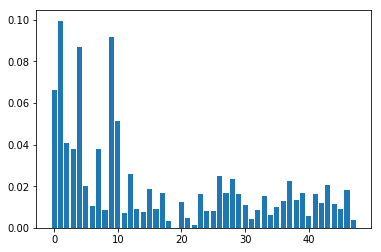

In [72]:
# feature importance
print(Rf_model.feature_importances_)
# plot
plt.bar(range(len(Rf_model.feature_importances_)), Rf_model.feature_importances_)
plt.show()

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [38]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
Dt_model=DecisionTreeClassifier(criterion='entropy',random_state=0)#fully grown tree (high bias error and var error)

In [43]:
# Use below values
num_folds = 10
seed = 77

In [44]:
#Validate the Random Forest model build above using k fold

In [45]:
models = []
models.append(('DecisionTree', Dt_model))
models.append(('RandomForest', Rf_model))


In [46]:
#Calculate Mean score

DecisionTree: 0.550095 (0.022706)
RandomForest: 0.444792 (0.021243)


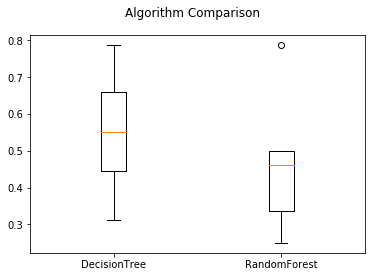

In [47]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [0]:
# Calculate score standard deviation using std()

DecisionTree: 0.150685 (0.022706)
RandomForest: 0.145750 (0.021243)


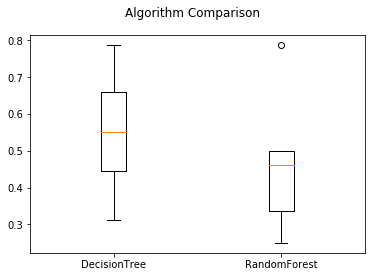

In [48]:
# evaluate each model in turn
results = []
names = []
scoring = 'recall'
for name, model in models:
	kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, np.std(cv_results), cv_results.var())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# Q8 Print the confusion matrix( 1 Marks)

In [49]:
cm=metrics.confusion_matrix(y_test,predicted)
print(cm)

[[93  8]
 [30 19]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [68]:
THRESHOLD = 0.30
preds = np.where(Rf_model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [69]:
pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds),
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.720000
recall,0.693878
precision,0.557377
f1Score,0.618182


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [0]:
#Hint: Use roc_curve

In [50]:
from sklearn.metrics import roc_curve, auc
y_predictProb = Rf_model.predict_proba(X_test)

In [51]:
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])

In [52]:
roc_auc = auc(fpr, tpr)
roc_auc

0.7989492826833704

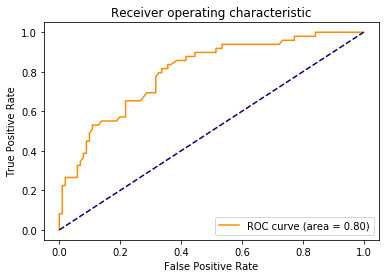

In [53]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [54]:
optimalF1 = 0
optimalTh = 0

In [57]:
for th in thresholds:
    preds = np.where(model.predict_proba(X_test)[:,1] > th, 1, 0)
    f1Score = f1_score(y_test, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        optimalTh = th

In [59]:
THRESHOLD = optimalTh

In [66]:
optimalTh

0.288

In [60]:
preds = np.where(Rf_model.predict_proba(X_test)[:,1] > THRESHOLD, 1, 0)

In [61]:
pd.DataFrame(data=[accuracy_score(y_test, preds), 
                   recall_score(y_test, preds),
                   precision_score(y_test, preds),
                   f1_score(y_test, preds)], 
             index=["accuracy", "recall", "precision", "f1Score"])

,0
accuracy,0.706667
recall,0.836735
precision,0.532468
f1Score,0.650794


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [62]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [64]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [65]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.7386666666666667
Standard deviation:  0.0195049851177704
